In [1]:
!pip install fft-conv-pytorch
!pip install scikit-image

In [127]:

import sys
from pathlib import Path

# Find GRAPHYCS root (folder that contains graphycs/forward_model_wf.py)
start = Path.cwd()
root = None
for p in [start, *start.parents]:
    if (p / "graphycs" / "forward_model_wf.py").exists():
        root = p
        break

pkg = root / "graphycs"
sys.path.insert(0, str(root))
sys.path.insert(0, str(pkg))

In [8]:
from datetime import datetime
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import skimage.io as skio
import torch.nn.functional as F
from torch.fft import fftshift, ifftshift, ifft2, fft2

# your helper modules (now in working dir)
from graphycs.forward_model_wf import forward_model_wf
from graphycs.utils import *
from graphycs.self_calibration import *

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
self_calib_param_lr    = 5e-4
learning_rate          = 5e-3
object_learning_rate     = 2e-3
seed                   = 0

data_path              = 'Data/Diversity_Images_Lymph.tif'
zernike_coeff_path     = 'Data/appliedCoeff.txt'


# ─── Calibration options ────────────────────────────────────────────────────────
use_self_calibration   = 1             # 1 or 0
use_learnable_scales   = 1             # 1 or 0
use_scheduler          = 0             # 1 or 0

# ─── Optimization hyperparameters ───────────────────────────────────────────────
epochs                 = 500
batch_size             = 22
use_batch_shuffling    = 0             # 1 or 0
use_L1_loss            = 1             # 1 or 0
fourier_loss_weight    = 1e-5

# ─── Visualization controls for training loop ───────────────────────────────────
vis_frequency          = 200
vis_intermediates      = 1             # keep in-memory stacks only

# ─── Zernike orders ─────────────────────────────────────────────────────────────
n_max                  = 14
n_max_estimated        = 14

# ─── Optical parameters ────────────────────────────────────────────────────────
NA                     = 0.3
camera_pixel_size      = 0.5343e-6
wavelength             = 0.513e-6
n_imm                  = 1.33
gaussian_sigma         = 10.0e-3

avg_background         = 0.0
psf_size               = 101
img_num_factor         = 1

### Dxp: diameter of the deformable mirror in m
Dxp = 10e-3
pad_w, pad_h = psf_size - 1, psf_size - 1

# ─── Zernike basis and defining the beam and Deformable mirror in the pupil plane────────────────────────────────────────────────────────────
M = 255
_, zernikes = zernike_pd_generation_higher_order(6, n_max, M, camera_pixel_size, wavelength, NA)
zernikes = zernikes.to(device)



n_max_ansi: 14
order_max: 6
[0, 2, 1, 4, 3, 5, 7, 8, 6, 9, 12, 13, 11, 14, 10, 18, 17, 19, 16, 20, 15, 24, 23, 25, 22, 26, 21, 27]


In [159]:
# ─── Setup seeds ────────────────────────────────────────────────────
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [160]:
# ─── Load applied coefficients ────────────────────────────────────────────────
coeffs = np.loadtxt(zernike_coeff_path)
coeffs = coeffs[::img_num_factor]
coeffs = torch.tensor(coeffs, dtype=torch.float32).to(device)

# coeffs[pair_idx]: known DM-applied Zernike coefficients for each diversity image.

# ─── Load data ────────────────────────────────────────────────────────────────
phase_added = skio.imread(data_path).astype(np.float32)
bg = np.min(phase_added[phase_added > 0])
phase_added = np.clip(phase_added - bg, 0, None)
phase_added /= phase_added.max()
phase_added = np.squeeze(phase_added)[::img_num_factor]
phase_added = torch.from_numpy(phase_added).to(device)

# phase_added: normalized observed diversity stack with shape [num_images, H, W].

# ─── Build learnable forward model ────────────────────────────────────────────
forward_model = forward_model_wf(
    init_object=phase_added[0].clone(),
    n_max=n_max,
    psf_size=psf_size,
    M=M,
    lmbda=wavelength,
    pixel_size=camera_pixel_size,
    n=n_imm,
    NA=NA,
    diversity_imgs_num=len(coeffs),
    device=device,
    use_affine_transform=bool(use_self_calibration),
    use_scales=bool(use_learnable_scales),
).to(device)


# Aliases used by downstream analysis cells.
found_zernike_coef = forward_model.zernike_coef
found_object = forward_model.estimated_obj

if use_self_calibration:
    print("Using affine transformation self calibration parameters in forward_model_wf")
    self_calib_params = [
        forward_model.amp_x,
        forward_model.amp_y,
        forward_model.off_x,
        forward_model.off_y,
        forward_model.rot,
        forward_model.grid,
    ]
else:
    print("Running without affine transformation self calibration")
    self_calib_params = []

if use_learnable_scales:
    print("Using learnable Zernike scaling factors in forward_model_wf")
    scale_factors_list = list(forward_model.scales)
else:
    print("Running without learnable Zernike scaling factors")
    scale_factors_list = []

optimizer_param_groups = [
    {'params': [found_zernike_coef], 'lr': learning_rate},
    {'params': [found_object], 'lr': object_learning_rate},
]

if use_self_calibration:
    for param in self_calib_params:
        optimizer_param_groups.append({'params': [param], 'lr': self_calib_param_lr})

if use_learnable_scales:
    for scale_factor in scale_factors_list:
        optimizer_param_groups.append({'params': [scale_factor], 'lr': self_calib_param_lr})

optimizer = torch.optim.Adam(optimizer_param_groups, lr=learning_rate)
if use_scheduler:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0)
L1_loss = torch.nn.L1Loss()


n_max_ansi: 14
order_max: 6
[0, 2, 1, 4, 3, 5, 7, 8, 6, 9, 12, 13, 11, 14, 10, 18, 17, 19, 16, 20, 15, 24, 23, 25, 22, 26, 21, 27]
Using affine transformation self calibration parameters in forward_model_wf
Using learnable Zernike scaling factors in forward_model_wf


In [161]:
## Freeze piston/tip/tilt and optional high-order modes during optimization.
mask = torch.ones_like(found_zernike_coef, device=device)
mask[:3] = 0
if n_max_estimated < len(mask):
    mask[n_max_estimated + 1:] = 0

train_loss_curve = []
image_loss_curve = []
fourier_loss_curve = []

found_object_stack = []
iPSF_stack = []
amplitudes_stack = []
generated_imgs = []

mse_loss = torch.nn.MSELoss()
do_vis = vis_frequency > 0

t = tqdm(range(epochs))
for epoch_idx in t:
    if use_batch_shuffling == 1:
        idxs = torch.randperm(len(coeffs)).long().to(device)
    else:
        idxs = torch.arange(len(coeffs)).long().to(device)

    forward_model.estimated_obj.requires_grad_()
    forward_model.zernike_coef.requires_grad_()

    epoch_train_loss = 0.0
    epoch_image_loss = 0.0
    epoch_fourier_loss = 0.0

    for it in range(0, len(coeffs), batch_size):
        idx = idxs[it:min(it + batch_size, len(coeffs))]
        coeff_batch, y_batch = coeffs[idx], phase_added[idx]

        optimizer.zero_grad()
        aberrated_imgs, psfs, amplitude_transformed = forward_model(coeff_batch, idx)

        recon_observed_imgs_FT = torch.real(torch.fft.fft2(aberrated_imgs, dim=(-2, -1)))
        observed_imgs_FT = torch.real(torch.fft.fft2(y_batch, dim=(-2, -1)))

        if use_L1_loss == 1:
            Fourier_loss = L1_loss(recon_observed_imgs_FT.squeeze(), observed_imgs_FT.squeeze())
            recon_loss = L1_loss(aberrated_imgs.squeeze(), y_batch.squeeze())
        else:
            Fourier_loss = mse_loss(recon_observed_imgs_FT.squeeze(), observed_imgs_FT.squeeze())
            recon_loss = mse_loss(aberrated_imgs.squeeze(), y_batch.squeeze())

        epoch_image_loss += recon_loss.item()
        epoch_fourier_loss += Fourier_loss.item()
        loss = recon_loss + fourier_loss_weight * Fourier_loss
        epoch_train_loss += loss.item()

        if do_vis and (epoch_idx % vis_frequency) == 0 and it == 0:
            psfs_squeezed = psfs.squeeze().detach().cpu().numpy()

            if vis_intermediates == 1:
                model_outputs_squeezed = aberrated_imgs.squeeze().detach().cpu().numpy()
                if model_outputs_squeezed.ndim == 3:
                    generated_imgs.append(model_outputs_squeezed[-1, :, :])
                elif model_outputs_squeezed.ndim == 2:
                    generated_imgs.append(model_outputs_squeezed)

            found_object_stack.append(forward_model.estimated_obj.detach().cpu().numpy())

            if psfs_squeezed.ndim == 3:
                iPSF_stack.append(psfs_squeezed[-1, :, :])
            elif psfs_squeezed.ndim == 2:
                iPSF_stack.append(psfs_squeezed)

            amplitudes_stack.append(amplitude_transformed.detach().cpu().numpy())

        loss.backward()

        if forward_model.zernike_coef.grad is not None:
            forward_model.zernike_coef.grad.mul_(mask)

        optimizer.step()

        if use_scheduler:
            scheduler.step()

        with torch.no_grad():
            forward_model.estimated_obj.data.clamp_(min=0.0)
            if use_learnable_scales:
                for p in forward_model.scales:
                    p.data.clamp_(min=-1.0)

    train_loss_curve.append(epoch_train_loss)
    image_loss_curve.append(epoch_image_loss)
    fourier_loss_curve.append(epoch_fourier_loss)

    t.set_description(
        f"Epoch {epoch_idx + 1}/{epochs}, Total loss: {epoch_train_loss:.4f}, Image domain loss: {epoch_image_loss:.4f}, Fourier domain loss: {epoch_fourier_loss:.4f}"
    )

# Keep explicit final handles to the trained model parameters for downstream cells.
trained_model = forward_model
final_found_object = trained_model.estimated_obj.detach()
final_found_zernike_coef = trained_model.zernike_coef.detach()


Epoch 500/500, Total loss: 0.0129, Image domain loss: 0.0128, Fourier domain loss: 3.1688: 100%|██████████| 500/500 [00:27<00:00, 18.09it/s]


In [151]:

# Base results path
base_results = "Results"

# Create a timestamp string, e.g. "20250429_163045"
ts = datetime.now().strftime("%Y%m%d_%H")

# Full path for this run
results_dir = os.path.join(base_results, ts)
os.makedirs(results_dir, exist_ok=True)

# Read final trained parameters directly from the trained model.
if 'trained_model' not in globals():
    trained_model = forward_model
final_found_zernike_coef = trained_model.zernike_coef.detach()
final_found_object = trained_model.estimated_obj.detach()

zernike_coeffs_np = final_found_zernike_coef.cpu().numpy()
found_obj_np = final_found_object.cpu().numpy()

# Save Zernike coefficients
np.savetxt(os.path.join(results_dir, "found_zernike_coefficients.txt"),
           zernike_coeffs_np, fmt="%.6e")

# Save reconstructed object
skio.imsave(os.path.join(results_dir, "estimated_object.tif"), found_obj_np)

# Save loss curves collected in training loop
np.save(os.path.join(results_dir, "train_loss_curve.npy"), np.array(train_loss_curve))
np.save(os.path.join(results_dir, "image_loss_curve.npy"), np.array(image_loss_curve))
np.save(os.path.join(results_dir, "fourier_loss_curve.npy"), np.array(fourier_loss_curve))


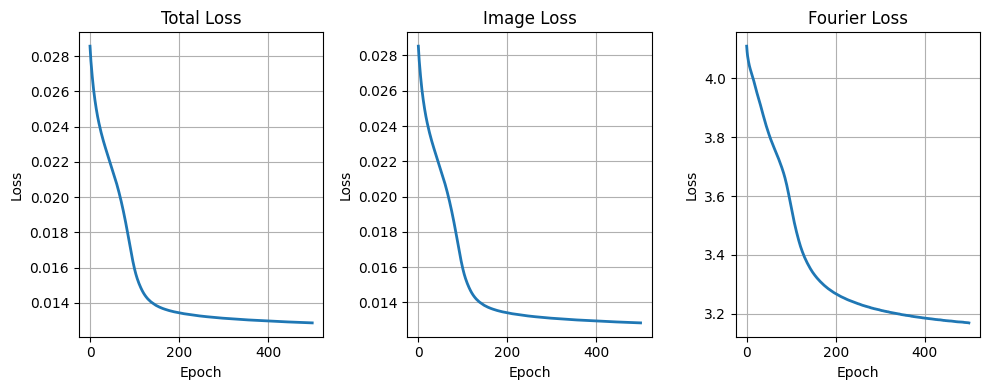

In [162]:
# — Plot training loss curves —
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.plot(train_loss_curve, lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(image_loss_curve, lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Image Loss')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(fourier_loss_curve, lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fourier Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


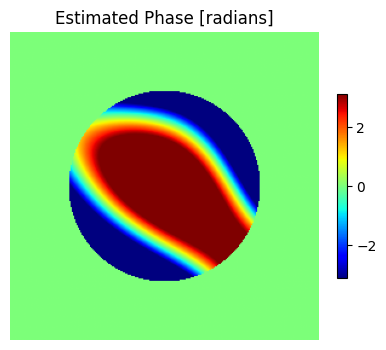

In [163]:
# — Compute & show estimated phase map from the trained model —
if 'trained_model' not in globals():
    trained_model = forward_model
final_found_zernike_coef = trained_model.zernike_coef.detach()

estimated_phase = torch.einsum('i,ijk->jk', 1e-6 * final_found_zernike_coef, zernikes)
est_phase_np = estimated_phase.detach().cpu().numpy()
est_phase_np = (2 * n_imm * np.pi / wavelength) * est_phase_np  # Convert from meters to radians

plt.figure(figsize=(5,4))
plt.imshow(est_phase_np, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.colorbar(shrink=0.6)
plt.title('Estimated Phase [radians]')
plt.axis('off')
plt.show()


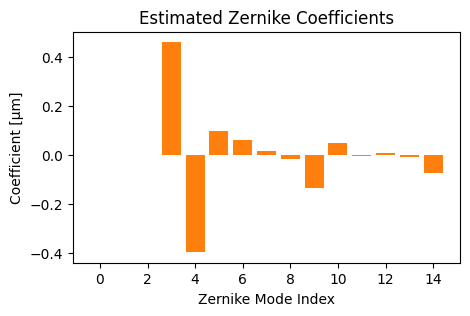

In [164]:
# — Bar chart of learned Zernike coefficients from the trained model —
if 'trained_model' not in globals():
    trained_model = forward_model
coeffs_np = trained_model.zernike_coef.detach().cpu().numpy()
modes = np.arange(len(coeffs_np))

plt.figure(figsize=(5,3))
plt.bar(modes, coeffs_np, color='C1')
plt.xlabel('Zernike Mode Index')
plt.ylabel('Coefficient [µm]')
plt.title('Estimated Zernike Coefficients')
plt.show()


In [165]:
## Estimated zernike coefficients:
print(coeffs_np)

[ 0.          0.          0.          0.4591221  -0.3953342   0.09772325
  0.0619496   0.01724124 -0.01693876 -0.13257387  0.04812621 -0.00457907
  0.01003424 -0.00593276 -0.07149281]


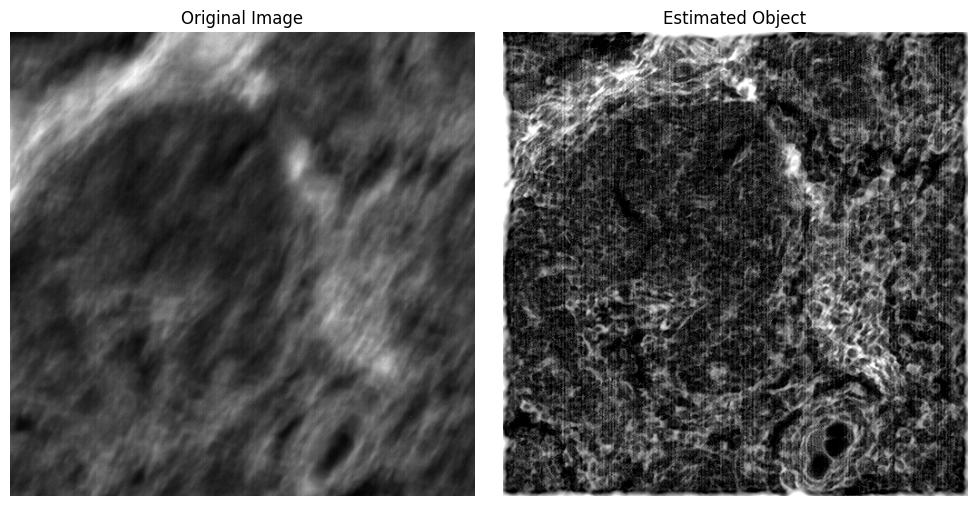

In [167]:
# Display original vs. trained-model estimated object side-by-side
if 'trained_model' not in globals():
    trained_model = forward_model
orig_np = phase_added[0].detach().cpu().numpy()
orig_np = (orig_np - orig_np.min()) / (orig_np.max() - orig_np.min())  # Normalize to [0, 1]
est_obj_np = trained_model.estimated_obj.detach().cpu().numpy()
est_min = est_obj_np.min()
est_p999 = np.percentile(est_obj_np, 99.9)
est_obj_np = np.clip((est_obj_np - est_min) / max(est_p999 - est_min, 1e-12), 0, 1)  # Min->0, 99.9th percentile->1

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(est_obj_np, cmap='gray', vmin=0, vmax=0.8)
axs[1].set_title('Estimated Object')
axs[1].axis('off')

plt.tight_layout()
plt.show()
